## 条件分支示例

温度：10 C
建议：穿厚外套


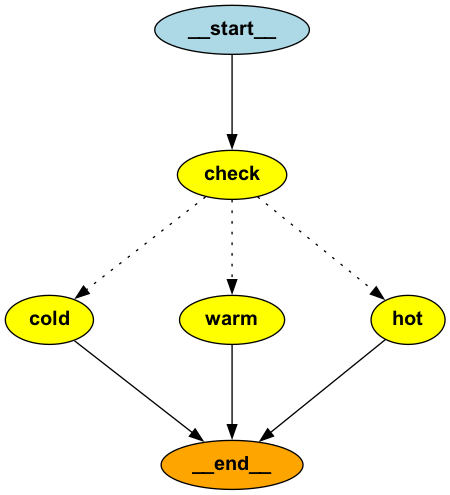

In [2]:
from typing import TypedDict, Literal
from langgraph.graph import StateGraph, START, END


class WeatherState(TypedDict):
    temperature: int
    recommendation: str


def check_temperature(state: WeatherState) -> dict:
    # 这里可以调用真实的天气查询 API
    return {"temperature": state["temperature"]}


def route_by_temperature(state: WeatherState) -> Literal["cold", "warm", "hot"]:
    """根据温度进行路由"""
    temp = state["temperature"]
    if temp < 15:
        return "cold"
    elif temp < 25:
        return "warm"
    else:
        return "hot"


def recommend_cold(state: WeatherState) -> dict:
    return {"recommendation": "穿厚外套"}


def recommend_warm(state: WeatherState) -> dict:
    return {"recommendation": "穿长袖就好"}


def recommend_hot(state: WeatherState) -> dict:
    return {"recommendation": "穿短袖，记得防晒！"}


# 构建图
graph = StateGraph(WeatherState)

graph.add_node("check", check_temperature)
graph.add_node("cold", recommend_cold)
graph.add_node("warm", recommend_warm)
graph.add_node("hot", recommend_hot)

graph.add_edge(START, "check")
graph.add_conditional_edges(
    "check",
    route_by_temperature,
    {
        "cold": "cold",
        "warm": "warm",
        "hot": "hot"
    }

)
for node in ["cold", "warm", "hot"]:
    graph.add_edge(node, END)

app = graph.compile()

# 测试
result = app.invoke({"temperature": 10})

print(f"温度：{result["temperature"]} C")
print(f"建议：{result["recommendation"]}")

# 打印图
from IPython.display import Image, display

try:
    display(Image(app.get_graph(xray=True).draw_png()))
except Exception as e:
    print(f"Graphviz 渲染失败: {e}")
    print("\n使用 Mermaid 文本方式显示:")
    print(app.get_graph(xray=True).draw_mermaid())